# Install Spark

The below comands will install spark locally in our colab instance.

In [2]:
# Colab: Java + PySpark
!apt-get update -y && apt-get install -y openjdk-17-jdk
!pip install -q pyspark==3.5.4
import os, subprocess
os.environ["JAVA_HOME"] = subprocess.check_output(
    "readlink -f /usr/bin/java | sed 's:/bin/java::'", shell=True
).decode().strip()
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("adult-mllib").getOrCreate()
print("Spark:", spark.version)

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 2s (2,028 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-17-jdk is already the newest version (17.0

## Exercise Overview
In this exercise we will play with Spark [Datasets & Dataframes](https://spark.apache.org/docs/latest/sql-programming-guide.html#datasets-and-dataframes), some [Spark SQL](https://spark.apache.org/docs/latest/sql-programming-guide.html#sql), and build a couple of binary classifiaction models using [Spark ML](https://spark.apache.org/docs/latest/ml-guide.html) (with some [MLlib](https://spark.apache.org/mllib/) too).
<br><br>
The set up and approach will not be too dissimilar to the standard type of approach you might do in [Sklearn](http://scikit-learn.org/stable/index.html). Spark has matured to the stage now where for 90% of what you need to do (when analysisng tabular data) should be possible with Spark dataframes, SQL, and ML libraries. This is where this exerise is mainly trying to focus.  
<br>

#### Links & References

Some useful links and references of sources used in creating this exercise:

**Note**: Right click and open as new tab!
<br>
1. [Latest Spark Docs](https://spark.apache.org/docs/latest/index.html)
1. [Databricks Homepage](https://databricks.com/)
1. [Databricks Community Edition FAQ](https://databricks.com/product/faq/community-edition)
1. [Databricks Self Paced Training](https://databricks.com/training-overview/training-self-paced)
1. [Databricks Notebook Guide](https://docs.databricks.com/user-guide/notebooks/index.html)
1. [Databricks Binary Classification Tutorial](https://docs.databricks.com/spark/latest/mllib/binary-classification-mllib-pipelines.html#binary-classification)

#### Get Data

Here we will pull in some sample data from the UCI data repository.

Feel free to adapt this notebook later to play around with a different dataset if you like (all available are listed in a cell below).

In [4]:
try:
    spark
except NameError:
    from pyspark.sql import SparkSession
    spark = (
        SparkSession.builder
        .master("local[*]")
        .appName("adult-colab")
        .getOrCreate()
    )

import pandas as pd

cols = [
    "age","workclass","fnlwgt","education","education_num","marital_status",
    "occupation","relationship","race","sex","capital_gain","capital_loss",
    "hours_per_week","native_country","income"
]

# SWAPPED: Using a GitHub mirror because UCI is returning a 502 error
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"

try:
    pdf = pd.read_csv(
        url,
        header=None,
        names=cols,
        skipinitialspace=True,
        na_values=["?", " ?"]
    )

    # Cleaning
    for c in pdf.select_dtypes(include="object").columns:
        pdf[c] = pdf[c].str.strip()

    pdf = pdf.dropna().reset_index(drop=True)

    # Convert to Spark
    sdf = spark.createDataFrame(pdf)

    # Spark SQL Operations
    spark.sql("CREATE DATABASE IF NOT EXISTS main")
    spark.sql("USE main")
    spark.sql("DROP TABLE IF EXISTS adult")

    sdf.createOrReplaceTempView("adult_src")

    spark.sql("""
    CREATE TABLE adult
    USING PARQUET
    AS SELECT * FROM adult_src
    """)

    spark.sql("CREATE OR REPLACE TEMP VIEW adult AS SELECT * FROM adult")

    # Verify
    spark.sql("SELECT COUNT(*) AS n_rows FROM adult").show()
    spark.sql("SELECT * FROM adult LIMIT 5").show()

except Exception as e:
    print(f"Error loading data: {e}")

+------+
|n_rows|
+------+
| 45222|
+------+

+---+----------------+------+-----------+-------------+------------------+---------------+--------------+-----+------+------------+------------+--------------+---------------+------+
|age|       workclass|fnlwgt|  education|education_num|    marital_status|     occupation|  relationship| race|   sex|capital_gain|capital_loss|hours_per_week| native_country|income|
+---+----------------+------+-----------+-------------+------------------+---------------+--------------+-----+------+------------+------------+--------------+---------------+------+
| 32|         Private|168138| Assoc-acdm|           12|          Divorced|          Sales| Not-in-family|White|  Male|        2597|           0|            48|  United-States| <=50K|
| 51|         Private|159755|  Bachelors|           13|Married-civ-spouse|Exec-managerial|       Husband|White|  Male|        7688|           0|            40|  United-States|  >50K|
| 42|         Private|191765|    HS-gra

#### Spark SQL
Below we will use Spark SQL to load in the data and then register it as a Dataframe aswell. So the end result will be a Spark SQL table called 'adult' and a Spark Dataframe called 'df_adult'.
<br><br>
This is an example of the flexibility in Spark in that you could do lots of you ETL and data wrangling using either Spark SQL or Dataframes and pyspark. Most of the time it's a case of using whatever you are most comfortable with.
<br><br>
When you get more advanced then you might consider learning about the pro's and con's of each and in what circumstances you might favour one over the other (or operating direclty on RDD's), [here](https://databricks.com/blog/2016/07/14/a-tale-of-three-apache-spark-apis-rdds-dataframes-and-datasets.html) is a good article on the issues. For now, no need to overthink it!

In [5]:
# look at the data
spark.sql("SELECT * FROM adult LIMIT 5").show()

+---+----------------+------+-----------+-------------+------------------+---------------+--------------+-----+------+------------+------------+--------------+---------------+------+
|age|       workclass|fnlwgt|  education|education_num|    marital_status|     occupation|  relationship| race|   sex|capital_gain|capital_loss|hours_per_week| native_country|income|
+---+----------------+------+-----------+-------------+------------------+---------------+--------------+-----+------+------------+------------+--------------+---------------+------+
| 32|         Private|168138| Assoc-acdm|           12|          Divorced|          Sales| Not-in-family|White|  Male|        2597|           0|            48|  United-States| <=50K|
| 51|         Private|159755|  Bachelors|           13|Married-civ-spouse|Exec-managerial|       Husband|White|  Male|        7688|           0|            40|  United-States|  >50K|
| 42|         Private|191765|    HS-grad|            9|     Never-married|   Adm-cler

If you are more comfortable with SQL then as you can see below, its very easy to just get going with writing standard SQL type code to analyse your data, do data wrangling and create new dataframes.

In [6]:
# Lets get some summary marital status rates by occupation
result = spark.sql(
  """
  SELECT
    occupation,
    SUM(1) as n,
    ROUND(AVG(if(LTRIM(marital_status) LIKE 'Married-%',1,0)),2) as married_rate,
    ROUND(AVG(if(lower(marital_status) LIKE '%widow%',1,0)),2) as widow_rate,
    ROUND(AVG(if(LTRIM(marital_status) = 'Divorced',1,0)),2) as divorce_rate,
    ROUND(AVG(if(LTRIM(marital_status) = 'Separated',1,0)),2) as separated_rate,
    ROUND(AVG(if(LTRIM(marital_status) = 'Never-married',1,0)),2) as bachelor_rate
  FROM
    adult
  GROUP BY 1
  ORDER BY n DESC
  """)
result.show()

+-----------------+----+------------+----------+------------+--------------+-------------+
|       occupation|   n|married_rate|widow_rate|divorce_rate|separated_rate|bachelor_rate|
+-----------------+----+------------+----------+------------+--------------+-------------+
|     Craft-repair|6020|        0.64|      0.01|        0.11|          0.03|         0.21|
|   Prof-specialty|6008|        0.52|      0.02|        0.13|          0.02|          0.3|
|  Exec-managerial|5984|         0.6|      0.03|        0.15|          0.02|         0.21|
|     Adm-clerical|5540|        0.28|      0.05|        0.21|          0.04|         0.42|
|            Sales|5408|        0.46|      0.03|        0.12|          0.03|         0.36|
|    Other-service|4808|        0.24|      0.05|        0.16|          0.06|          0.5|
|Machine-op-inspct|2970|         0.5|      0.03|        0.14|          0.04|         0.29|
| Transport-moving|2316|        0.65|      0.02|        0.11|          0.02|          0.2|

You can easily register dataframes as a table for Spark SQL too. So this way you can easily move between Dataframes and Spark SQL for whatever reason.

In [7]:
# register the df we just made as a table for spark sql
result.createOrReplaceTempView("result")
spark.sql("SELECT * FROM result").show(5)

+---------------+----+------------+----------+------------+--------------+-------------+
|     occupation|   n|married_rate|widow_rate|divorce_rate|separated_rate|bachelor_rate|
+---------------+----+------------+----------+------------+--------------+-------------+
|   Craft-repair|6020|        0.64|      0.01|        0.11|          0.03|         0.21|
| Prof-specialty|6008|        0.52|      0.02|        0.13|          0.02|          0.3|
|Exec-managerial|5984|         0.6|      0.03|        0.15|          0.02|         0.21|
|   Adm-clerical|5540|        0.28|      0.05|        0.21|          0.04|         0.42|
|          Sales|5408|        0.46|      0.03|        0.12|          0.03|         0.36|
+---------------+----+------------+----------+------------+--------------+-------------+
only showing top 5 rows



#### <span style="color:darkblue">Question 1</span>

1. Write some spark sql to get the top 'bachelor_rate' by 'education' group?

In [10]:
### Question 1.1 Answer ###

result = spark.sql("""
SELECT
    education,
    COUNT(*) as n,
    ROUND(AVG(IF(LTRIM(marital_status) = 'Never-married', 1, 0)), 2) as bachelor_rate
FROM
    adult
GROUP BY
    education
ORDER BY
    bachelor_rate DESC
    """)
result.show()

+------------+-----+-------------+
|   education|    n|bachelor_rate|
+------------+-----+-------------+
|        12th|  577|         0.52|
|   Preschool|   72|         0.51|
|        11th| 1619|         0.49|
|Some-college| 9899|         0.38|
|        10th| 1223|         0.36|
|   Bachelors| 7570|         0.34|
|  Assoc-acdm| 1507|         0.32|
|         9th|  676|         0.29|
|     HS-grad|14783|         0.29|
|     5th-6th|  449|         0.26|
|   Assoc-voc| 1959|         0.26|
|     Masters| 2514|         0.24|
|     1st-4th|  222|         0.22|
|     7th-8th|  823|         0.17|
|   Doctorate|  544|         0.17|
| Prof-school|  785|         0.17|
+------------+-----+-------------+



#### Spark DataFrames
Below we will create our DataFrame from the SQL table and do some similar analysis as we did with Spark SQL but using the DataFrames API.

In [11]:
# register a df from the sql df
df_adult = spark.table("adult")
cols = df_adult.columns # this will be used much later in the notebook, ignore for now

In [12]:
# look at df schema
df_adult.printSchema()

root
 |-- age: long (nullable = true)
 |-- workclass: string (nullable = true)
 |-- fnlwgt: long (nullable = true)
 |-- education: string (nullable = true)
 |-- education_num: long (nullable = true)
 |-- marital_status: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- relationship: string (nullable = true)
 |-- race: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- capital_gain: long (nullable = true)
 |-- capital_loss: long (nullable = true)
 |-- hours_per_week: long (nullable = true)
 |-- native_country: string (nullable = true)
 |-- income: string (nullable = true)



In [13]:
# look at the df
df_adult.show(5)

+---+----------------+------+-----------+-------------+------------------+---------------+--------------+-----+------+------------+------------+--------------+---------------+------+
|age|       workclass|fnlwgt|  education|education_num|    marital_status|     occupation|  relationship| race|   sex|capital_gain|capital_loss|hours_per_week| native_country|income|
+---+----------------+------+-----------+-------------+------------------+---------------+--------------+-----+------+------------+------------+--------------+---------------+------+
| 32|         Private|168138| Assoc-acdm|           12|          Divorced|          Sales| Not-in-family|White|  Male|        2597|           0|            48|  United-States| <=50K|
| 51|         Private|159755|  Bachelors|           13|Married-civ-spouse|Exec-managerial|       Husband|White|  Male|        7688|           0|            40|  United-States|  >50K|
| 42|         Private|191765|    HS-grad|            9|     Never-married|   Adm-cler

Below we will do a similar calulation to what we did above but using the DataFrames API

In [15]:
from pyspark.sql.functions import when, col, mean, desc, round, trim

# 1. Wrangle the data: Trim the whitespace and create the binary flag
# 2. Group by occupation
# 3. Aggregate to find the rate
# 4. Order by the highest rate first
df_divorce_analysis = (
    df_adult
    .select(
        'occupation',
        when(trim(col('marital_status')) == 'Divorced', 1)
        .otherwise(0)
        .alias('is_divorced')
    )
    .groupBy('occupation')
    .agg(round(mean('is_divorced'), 2).alias('divorced_rate'))
    .orderBy(desc('divorced_rate'))
)

# Show the results
df_divorce_analysis.show(5)

+---------------+-------------+
|     occupation|divorced_rate|
+---------------+-------------+
|   Adm-clerical|         0.21|
|Priv-house-serv|         0.19|
|   Tech-support|         0.16|
|  Other-service|         0.16|
|Exec-managerial|         0.15|
+---------------+-------------+
only showing top 5 rows



As you can see the dataframes api is a bit more verbose then just expressing what you want to do in standard SQL.<br><br>But some prefer it and might be more used to it, and there could be cases where expressing what you need to do might just be better using the DataFrame API if it is too complicated for a simple SQL expression for example of maybe involves recursion of some type.

#### <span style="color:darkblue">Question 2</span>
1. Write some pyspark to get the top 'bachelor_rate' by 'education' group using DataFrame operations?

In [19]:
### Question 2.1 Answer ###
from pyspark.sql.functions import when, col, mean, desc, round, trim, count
# wrangle the data a bit
df_result = (
    df_adult
    .select(
        'education',
        when(trim(col('marital_status')) == 'Never-married', 1)
        .otherwise(0)
        .alias('is_bachelor')
    )
    .groupBy('education')
    .agg(
        round(mean('is_bachelor'), 2).alias('bachelor_rate'),
        count("*").alias("n")  # Corrected: Use count("*") instead of col('count')
    )
    .orderBy(desc('bachelor_rate'))
)
df_result.show(5)

+------------+-------------+----+
|   education|bachelor_rate|   n|
+------------+-------------+----+
|        12th|         0.52| 577|
|   Preschool|         0.51|  72|
|        11th|         0.49|1619|
|Some-college|         0.38|9899|
|        10th|         0.36|1223|
+------------+-------------+----+
only showing top 5 rows



#### Explore & Visualize Data
It's very easy to [collect()](https://spark.apache.org/docs/latest/rdd-programming-guide.html#printing-elements-of-an-rdd) your Spark DataFrame data into a Pandas df and then continue to analyse or plot as you might normally.
<br><br>
Obviously if you try to collect() a huge DataFrame then you will run into issues, so usually you would only collect aggregated or sampled data into a Pandas df.

In [20]:
import pandas as pd

# do some analysis
result = spark.sql(
  """
  SELECT
    occupation,
    AVG(IF(income = ' >50K',1,0)) as plus_50k
  FROM
    adult
  GROUP BY 1
  ORDER BY 2 DESC
  """)

# collect results into a pandas df
df_pandas = pd.DataFrame(
  result.collect(),
  columns=result.schema.names
)

# look at df
print(df_pandas.head())

          occupation  plus_50k
0              Sales       0.0
1    Exec-managerial       0.0
2     Prof-specialty       0.0
3  Handlers-cleaners       0.0
4    Farming-fishing       0.0


In [21]:
print(df_pandas.describe())

       plus_50k
count      14.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0


In [22]:
print(df_pandas.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   occupation  14 non-null     object 
 1   plus_50k    14 non-null     float64
dtypes: float64(1), object(1)
memory usage: 356.0+ bytes
None


Here we will just do some very basic plotting to show how you might collect what you are interested in into a Pandas DF and then just plot any way you normally would.

For simplicity we are going to use the plotting functionality built into pandas (you could make this a pretty as you want).

        occupation  plus_50k
0  Exec-managerial  0.479111
1   Prof-specialty  0.450067
2  Protective-serv  0.314549
3     Tech-support  0.289437
4     Armed-Forces  0.285714


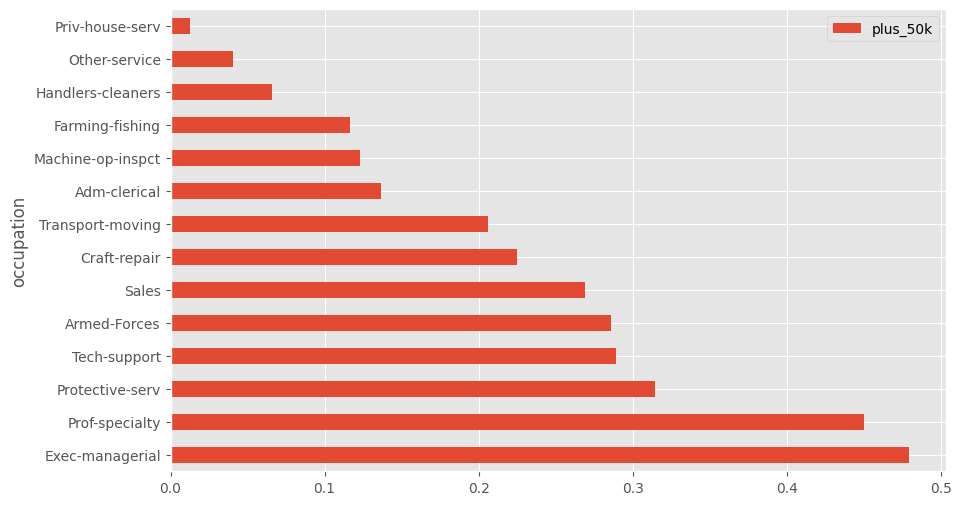

In [24]:
import matplotlib.pyplot as plt

result = spark.sql("""
  SELECT
    occupation,
    AVG(IF(TRIM(income) = '>50K', 1, 0)) as plus_50k
  FROM
    adult
  GROUP BY 1
  ORDER BY 2 DESC
""")

# Convert to Pandas
df_pandas = result.toPandas()

# Verify the data isn't all zeros before plotting
print(df_pandas.head())

# Now plot
plt.style.use('ggplot')
df_pandas.plot(kind='barh', x='occupation', y='plus_50k', figsize=(10, 6))
plt.show()

You can also easily get summary stats on a Spark DataFrame like below. [Here](https://databricks.com/blog/2015/06/02/statistical-and-mathematical-functions-with-dataframes-in-spark.html) is a nice blog post that has more examples.<br><br>So this is an example of why you might want to move from Spark SQL into DataFrames API as being able to just call describe() on the Spark DF is easier then trying to do the equivilant in Spark SQL.

In [25]:
# describe df
df_adult.select(df_adult['age'],df_adult['education_num']).describe().show()

+-------+------------------+------------------+
|summary|               age|     education_num|
+-------+------------------+------------------+
|  count|             45222|             45222|
|   mean|38.547941267524656|10.118460041572686|
| stddev|13.217870219055566|2.5528811950758694|
|    min|                17|                 1|
|    max|                90|                16|
+-------+------------------+------------------+



### ML Pipeline - Logistic Regression vs Random Forest

Below we will create two [Spark ML Pipelines](https://spark.apache.org/docs/latest/ml-pipeline.html) - one that fits a logistic regression and one that fits a random forest. We will then compare the performance of each.

**Note**: A lot of the code below is adapted from [this example](https://docs.databricks.com/spark/latest/mllib/binary-classification-mllib-pipelines.html).

In [26]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler

categoricalColumns = ["workclass", "education", "marital_status", "occupation", "relationship", "race", "sex", "native_country"]
stages = [] # stages in our Pipeline

for categoricalCol in categoricalColumns:
    # Category Indexing with StringIndexer
    stringIndexer = StringIndexer(inputCol=categoricalCol, outputCol=categoricalCol + "Index")
    # Use OneHotEncoder to convert categorical variables into binary SparseVectors
    # encoder = OneHotEncoderEstimator(inputCol=categoricalCol + "Index", outputCol=categoricalCol + "classVec")
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    # Add stages.  These are not run here, but will run all at once later on.
    stages += [stringIndexer, encoder]

In [27]:
# Convert label into label indices using the StringIndexer
label_stringIdx = StringIndexer(inputCol="income", outputCol="label")
stages += [label_stringIdx]

In [28]:
# Transform all features into a vector using VectorAssembler
numericCols = ["age", "fnlwgt", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

In [29]:
# Create a Pipeline.
pipeline = Pipeline(stages=stages)
# Run the feature transformations.
#  - fit() computes feature statistics as needed.
#  - transform() actually transforms the features.
pipelineModel = pipeline.fit(df_adult)
dataset = pipelineModel.transform(df_adult)
# Keep relevant columns
selectedcols = ["label", "features"] + cols
dataset = dataset.select(selectedcols)
dataset.show()

+-----+--------------------+---+----------------+------+------------+-------------+------------------+----------------+--------------+------------------+------+------------+------------+--------------+---------------+------+
|label|            features|age|       workclass|fnlwgt|   education|education_num|    marital_status|      occupation|  relationship|              race|   sex|capital_gain|capital_loss|hours_per_week| native_country|income|
+-----+--------------------+---+----------------+------+------------+-------------+------------------+----------------+--------------+------------------+------+------------+------------+--------------+---------------+------+
|  0.0|(96,[0,12,23,31,4...| 32|         Private|168138|  Assoc-acdm|           12|          Divorced|           Sales| Not-in-family|             White|  Male|        2597|           0|            48|  United-States| <=50K|
|  1.0|(96,[0,8,21,29,40...| 51|         Private|159755|   Bachelors|           13|Married-civ-spous

In [30]:
### Randomly split data into training and test sets. set seed for reproducibility
(trainingData, testData) = dataset.randomSplit([0.7, 0.3], seed=100)
print(trainingData.count())
print(testData.count())

31691
13531


In [31]:
from pyspark.sql.functions import avg

# get the rate of the positive outcome from the training data to use as a threshold in the model
training_data_positive_rate = trainingData.select(avg(trainingData['label'])).collect()[0][0]

print("Positive rate in the training data is {}".format(training_data_positive_rate))

Positive rate in the training data is 0.24742040326906692


#### Logistic Regression - Train

In [32]:
from pyspark.ml.classification import LogisticRegression

# Create initial LogisticRegression model
lr = LogisticRegression(labelCol="label", featuresCol="features", maxIter=10)

# set threshold for the probability above which to predict a 1
lr.setThreshold(training_data_positive_rate)
# lr.setThreshold(0.5) # could use this if knew you had balanced data

# Train model with Training Data
lrModel = lr.fit(trainingData)

# get training summary used for eval metrics and other params
lrTrainingSummary = lrModel.summary

# Find the best model threshold if you would like to use that instead of the empirical positve rate
fMeasure = lrTrainingSummary.fMeasureByThreshold
maxFMeasure = fMeasure.groupBy().max('F-Measure').select('max(F-Measure)').head()
lrBestThreshold = fMeasure.where(fMeasure['F-Measure'] == maxFMeasure['max(F-Measure)']) \
    .select('threshold').head()['threshold']

print("Best threshold based on model performance on training data is {}".format(lrBestThreshold))

Best threshold based on model performance on training data is 0.3611316155689799


#### GBM - Train

#### <span style="color:darkblue">Question 3</span>
1. Train a GBTClassifier on the training data, call the trained model 'gbModel'

In [34]:
### Question 3.1 Answer ###

from pyspark.ml.classification import GBTClassifier

# Create initial GBT model
# Note: maxIter is the number of boosting steps (trees)
gb = GBTClassifier(labelCol="label", featuresCol="features", maxIter=10, seed=100)

# Train model with Training Data
gbModel = gb.fit(trainingData)

#### Logistic Regression - Predict

In [35]:
# make predictions on test data
lrPredictions = lrModel.transform(testData)

# display predictions
lrPredictions.select("label", "prediction", "probability").show()

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       1.0|[0.56691590560558...|
|  0.0|       1.0|[0.50155502750531...|
|  0.0|       1.0|[0.55829228167297...|
|  0.0|       1.0|[0.48284726241396...|
|  0.0|       1.0|[0.37091015754662...|
|  0.0|       1.0|[0.62289552546180...|
|  0.0|       1.0|[0.34358211878532...|
|  0.0|       1.0|[0.61733796562166...|
|  0.0|       1.0|[0.42022444643884...|
|  0.0|       1.0|[0.42240880815172...|
|  0.0|       1.0|[0.35727966142497...|
|  0.0|       1.0|[0.35592293187916...|
|  0.0|       1.0|[0.47221440527952...|
|  0.0|       0.0|[0.87660252518635...|
|  0.0|       0.0|[0.79598683341946...|
|  0.0|       0.0|[0.83423223705614...|
|  0.0|       0.0|[0.81394725972506...|
|  0.0|       0.0|[0.80915522899895...|
|  0.0|       1.0|[0.67434394932451...|
|  0.0|       1.0|[0.72996646164771...|
+-----+----------+--------------------+
only showing top 20 rows



### GBM - Predict

#### <span style="color:darkblue">Question 4</span>
1. Get predictions on the test data for your GBTClassifier. Call the predictions df 'gbPredictions'.

In [36]:
### Question 4.1 Answer ###

# make predictions on test data
gbPredictions = gbModel.transform(testData)

# View the results
gbPredictions.select("label", "prediction", "probability").show()

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       0.0|[0.79953500658604...|
|  0.0|       1.0|[0.36720378295602...|
|  0.0|       0.0|[0.66418387644960...|
|  0.0|       1.0|[0.36720378295602...|
|  0.0|       1.0|[0.36720378295602...|
|  0.0|       0.0|[0.77219321491333...|
|  0.0|       1.0|[0.36720378295602...|
|  0.0|       0.0|[0.76798234622082...|
|  0.0|       1.0|[0.23803201266243...|
|  0.0|       0.0|[0.66418387644960...|
|  0.0|       0.0|[0.62953439413492...|
|  0.0|       1.0|[0.25637574662393...|
|  0.0|       1.0|[0.40523644130387...|
|  0.0|       0.0|[0.83961996320263...|
|  0.0|       0.0|[0.83961996320263...|
|  0.0|       0.0|[0.83961996320263...|
|  0.0|       0.0|[0.83961996320263...|
|  0.0|       0.0|[0.83961996320263...|
|  0.0|       0.0|[0.82764715230237...|
|  0.0|       0.0|[0.82764715230237...|
+-----+----------+--------------------+
only showing top 20 rows



#### Logistic Regression - Evaluate

#### <span style="color:darkblue">Question 5</span>
1. Complete the print_performance_metrics() function below to also include measures of F1, Precision, Recall, False Positive Rate and True Positive Rate.

In [39]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics

def print_performance_metrics(predictions):
    # 1. Evaluate model using the Dataframe-based Evaluator
    evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
    auc = evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})
    aupr = evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderPR"})

    print("Area under ROC (from Evaluator) = {:.4f}".format(auc))
    print("Area under PR (from Evaluator) = {:.4f}".format(aupr))

    # 2. Convert to RDD for mllib-based metrics
    # We cast to float to ensure compatibility with MulticlassMetrics
    predictionAndLabels = predictions.select("prediction", "label").rdd.map(lambda r: (float(r[0]), float(r[1])))

    # 3. Instantiate metrics objects
    binary_metrics = BinaryClassificationMetrics(predictionAndLabels)
    multi_metrics = MulticlassMetrics(predictionAndLabels)

    # 4. Standard Metrics
    print("Accuracy = {:.4f}".format(multi_metrics.accuracy))
    print("\nConfusion Matrix:")
    print(multi_metrics.confusionMatrix().toArray())

    ### Question 5.1 Answer ###
    # We use 1.0 as the label because we are interested in the ">50K" class

    # F1 Score
    print("F1 = {:.4f}".format(multi_metrics.fMeasure(1.0)))

    # Precision
    print("Precision = {:.4f}".format(multi_metrics.precision(1.0)))

    # Recall
    print("Recall = {:.4f}".format(multi_metrics.recall(1.0)))

    # False Positive Rate (FPR)
    print("FPR = {:.4f}".format(multi_metrics.falsePositiveRate(1.0)))

    # True Positive Rate (TPR)
    print("TPR = {:.4f}".format(multi_metrics.truePositiveRate(1.0)))

# --- Run the performance check ---

print("--- Logistic Regression Performance ---")
print_performance_metrics(lrPredictions)

print("\n" + "="*40 + "\n")

print("--- GBT Performance ---")
print_performance_metrics(gbPredictions)

--- Logistic Regression Performance ---
Area under ROC (from Evaluator) = 0.9052
Area under PR (from Evaluator) = 0.7699


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Accuracy = 0.8121

Confusion Matrix:
[[8145. 2019.]
 [ 523. 2844.]]
F1 = 0.6911
Precision = 0.5848
Recall = 0.8447
FPR = 0.1986
TPR = 0.8447


--- GBT Performance ---
Area under ROC (from Evaluator) = 0.9063
Area under PR (from Evaluator) = 0.7812
Accuracy = 0.8461

Confusion Matrix:
[[9509.  655.]
 [1427. 1940.]]
F1 = 0.6508
Precision = 0.7476
Recall = 0.5762
FPR = 0.0644
TPR = 0.5762


#### GBM - Evaluate

In [40]:
print_performance_metrics(gbPredictions)

Area under ROC (from Evaluator) = 0.9063
Area under PR (from Evaluator) = 0.7812
Accuracy = 0.8461

Confusion Matrix:
[[9509.  655.]
 [1427. 1940.]]
F1 = 0.6508
Precision = 0.7476
Recall = 0.5762
FPR = 0.0644
TPR = 0.5762


## Cross Validation

For each model you can run the below comand to see its params and a brief explanation of each.

In [41]:
print(lr.explainParams())

aggregationDepth: suggested depth for treeAggregate (>= 2). (default: 2)
elasticNetParam: the ElasticNet mixing parameter, in range [0, 1]. For alpha = 0, the penalty is an L2 penalty. For alpha = 1, it is an L1 penalty. (default: 0.0)
family: The name of family which is a description of the label distribution to be used in the model. Supported options: auto, binomial, multinomial (default: auto)
featuresCol: features column name. (default: features, current: features)
fitIntercept: whether to fit an intercept term. (default: True)
labelCol: label column name. (default: label, current: label)
lowerBoundsOnCoefficients: The lower bounds on coefficients if fitting under bound constrained optimization. The bound matrix must be compatible with the shape (1, number of features) for binomial regression, or (number of classes, number of features) for multinomial regression. (undefined)
lowerBoundsOnIntercepts: The lower bounds on intercepts if fitting under bound constrained optimization. The

In [42]:
print(gb.explainParams())

cacheNodeIds: If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval. (default: False)
checkpointInterval: set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext. (default: 10)
featureSubsetStrategy: The number of features to consider for splits at each tree node. Supported options: 'auto' (choose automatically for task: If numTrees == 1, set to 'all'. If numTrees > 1 (forest), set to 'sqrt' for classification and to 'onethird' for regression), 'all' (use all features), 'onethird' (use 1/3 of the features), 'sqrt' (use sqrt(number of features)), 'log2' (use log2(number of features)), 

#### Logisitic Regression - Param Grid

In [43]:
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Create ParamGrid for Cross Validation
lrParamGrid = (ParamGridBuilder()
             .addGrid(lr.regParam, [0.01, 0.5, 2.0])
             .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
             .addGrid(lr.maxIter, [2, 5])
             .build())

#### GBM - Param Grid

#### <span style="color:darkblue">Question 6</span>
1. Build out a param grid for the gb model, call it 'gbParamGrid'.

In [44]:
### Question 6.1 Answer ###

# Create ParamGrid for Cross Validation
from pyspark.ml.tuning import ParamGridBuilder

# Create ParamGrid for GBT Cross Validation

gbParamGrid = (ParamGridBuilder()
             .addGrid(gb.maxDepth, [2, 5, 10])
             .addGrid(gb.maxIter, [10, 20])
             .build())

#### Logistic Regression - Perform Cross Validation

In [45]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics

# set up an evaluator
evaluator = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")

# Create CrossValidator
lrCv = CrossValidator(estimator=lr, estimatorParamMaps=lrParamGrid, evaluator=evaluator, numFolds=2)

# Run cross validations
lrCvModel = lrCv.fit(trainingData)
# this will likely take a fair amount of time because of the amount of models that we're creating and testing

In [46]:
# below approach to getting at the best params from the best cv model taken from:
# https://stackoverflow.com/a/46353730/1919374

# look at best params from the CV
print(lrCvModel.bestModel._java_obj.getRegParam())
print(lrCvModel.bestModel._java_obj.getElasticNetParam())
print(lrCvModel.bestModel._java_obj.getMaxIter())

0.01
0.0
5


#### GBM - Perform Cross Validation

#### <span style="color:darkblue">Question 7</span>
1. Perform cross validation of params on your 'gb' model.
1. Print out the best params you found.

In [48]:
### Question 7.1 Answer ###

# Create CrossValidator
gbCv = CrossValidator(estimator=gb,
                      estimatorParamMaps=gbParamGrid,
                      evaluator=evaluator,
                      numFolds=2)

# 2. Run the cross-validation (this will take a few minutes)
gbCvModel = gbCv.fit(trainingData)

In [50]:
### Question 7.2 Answer ###

# look at best params from the CV
bestGB = gbCvModel.bestModel
print("Best maxDepth: {}".format(bestGB.getMaxDepth()))
print("Best maxIter:  {}".format(bestGB.getMaxIter()))

Best maxDepth: 5
Best maxIter:  20


#### Logistic Regression - CV Model Predict

In [51]:
# Use test set to measure the accuracy of our model on new data
lrCvPredictions = lrCvModel.transform(testData)

lrCvPredictions.show()

+-----+--------------------+---+---------+------+---------+-------------+------------------+------------+------------+-----+----+------------+------------+--------------+--------------+------+--------------------+--------------------+----------+
|label|            features|age|workclass|fnlwgt|education|education_num|    marital_status|  occupation|relationship| race| sex|capital_gain|capital_loss|hours_per_week|native_country|income|       rawPrediction|         probability|prediction|
+-----+--------------------+---+---------+------+---------+-------------+------------------+------------+------------+-----+----+------------+------------+--------------+--------------+------+--------------------+--------------------+----------+
|  0.0|(96,[0,6,21,27,40...| 28|  Private|340269|  HS-grad|            9|Married-civ-spouse|Craft-repair|     Husband|White|Male|        3137|           0|            45| United-States| <=50K|[0.76527818247891...|[0.68249858580128...|       1.0|
|  0.0|(96,[0,6,

#### GBM - CV Model Predict

In [52]:
gbCvPredictions = gbCvModel.transform(testData)

gbCvPredictions.show()

+-----+--------------------+---+---------+------+---------+-------------+------------------+------------+------------+-----+----+------------+------------+--------------+--------------+------+--------------------+--------------------+----------+
|label|            features|age|workclass|fnlwgt|education|education_num|    marital_status|  occupation|relationship| race| sex|capital_gain|capital_loss|hours_per_week|native_country|income|       rawPrediction|         probability|prediction|
+-----+--------------------+---+---------+------+---------+-------------+------------------+------------+------------+-----+----+------------+------------+--------------+--------------+------+--------------------+--------------------+----------+
|  0.0|(96,[0,6,21,27,40...| 28|  Private|340269|  HS-grad|            9|Married-civ-spouse|Craft-repair|     Husband|White|Male|        3137|           0|            45| United-States| <=50K|[0.72969842214458...|[0.81144040635822...|       0.0|
|  0.0|(96,[0,6,

#### Logistic Regression - CV Model Evaluate

In [53]:
print_performance_metrics(lrCvPredictions)

Area under ROC (from Evaluator) = 0.9013
Area under PR (from Evaluator) = 0.7531
Accuracy = 0.8016

Confusion Matrix:
[[7984. 2180.]
 [ 504. 2863.]]
F1 = 0.6809
Precision = 0.5677
Recall = 0.8503
FPR = 0.2145
TPR = 0.8503


#### GBM - CV Model Evaluate

In [54]:
print_performance_metrics(gbCvPredictions)

Area under ROC (from Evaluator) = 0.9099
Area under PR (from Evaluator) = 0.7882
Accuracy = 0.8499

Confusion Matrix:
[[9511.  653.]
 [1378. 1989.]]
F1 = 0.6620
Precision = 0.7528
Recall = 0.5907
FPR = 0.0642
TPR = 0.5907


#### Logistic Regression - Model Explore

In [55]:
print('Model Intercept: ', lrCvModel.bestModel.intercept)

Model Intercept:  -5.959997844536553


In [ ]:
lrWeights = lrCvModel.bestModel.coefficients
lrWeights = [(float(w),) for w in lrWeights]  # convert numpy type to float, and to tuple
lrWeightsDF = spark.createDataFrame(lrWeights, ["Feature Weight"])
lrWeightsDF.show()

+--------------------+
|      Feature Weight|
+--------------------+
| 0.15223697579930323|
| -0.3228707168897386|
|                 0.0|
| -0.1624475667166901|
|  0.1283413483727274|
| 0.22460395028914307|
|-0.06718453658168749|
|                 0.0|
|  0.3526793423601534|
|  0.4355196878504106|
|                 0.0|
|-0.05445209191448029|
|                 0.0|
|-0.05504706679412582|
| -0.2299436142971662|
|  0.7758622309786092|
|-0.02216204920866067|
|                 0.0|
|  0.5691645341368106|
|                 0.0|
+--------------------+
only showing top 20 rows



### Feature Importance

#### <span style="color:darkblue">Question 8</span>
1. Print out a table of feature_name and feature_coefficient from the Logistic Regression model.
<br><br>
Hint: Adapt the code from here: https://stackoverflow.com/questions/42935914/how-to-map-features-from-the-output-of-a-vectorassembler-back-to-the-column-name

In [56]:
### Question 8.1 Answer ###

# from: https://stackoverflow.com/questions/42935914/how-to-map-features-from-the-output-of-a-vectorassembler-back-to-the-column-name

import pandas as pd

# 1. Extract the feature names from the metadata of the 'features' column
# This handles both numeric columns and the expanded One-Hot Encoded categories
attrs = dataset.schema["features"].metadata["ml_attr"]["attrs"]

# Combine numeric (binary) and nominal (one-hot) attributes into one list
list_extract = []
for i in attrs:
    for j in attrs[i]:
        list_extract.append((j['idx'], j['name']))

# Sort by index to ensure they align with the coefficient vector
feature_names = [x[1] for x in sorted(list_extract, key=lambda x: x[0])]

# 2. Get the coefficients from the best model
coefficients = lrCvModel.bestModel.coefficients.toArray()

# 3. Create a pandas DataFrame for a clean, readable table
coef_table = pd.DataFrame(list(zip(feature_names, coefficients)),
                          columns=['Feature Name', 'Coefficient'])

# Sort by the absolute value of the coefficient to see the most impactful features
coef_table['Abs_Coefficient'] = coef_table['Coefficient'].abs()
coef_table = coef_table.sort_values(by='Abs_Coefficient', ascending=False).drop('Abs_Coefficient', axis=1)

print(coef_table)

                              Feature Name   Coefficient
83  native_countryclassVec_Trinadad&Tobago -2.201349e+00
68         native_countryclassVec_Columbia -1.730584e+00
87         native_countryclassVec_Scotland -1.370582e+00
44               relationshipclassVec_Wife  1.236679e+00
15           educationclassVec_Prof-school  1.074395e+00
..                                     ...           ...
70            native_countryclassVec_Haiti  1.002562e-02
10             educationclassVec_Assoc-voc  2.124847e-03
94                            capital_loss  4.901306e-04
93                            capital_gain  9.258843e-05
91                                  fnlwgt  6.421663e-07

[96 rows x 2 columns]


In [58]:
attrs = dataset.schema["features"].metadata["ml_attr"]["attrs"]

# Create a flat list of (index, name) pairs from all attribute types
feature_map = []
for attr_type in attrs:
    for attr in attrs[attr_type]:
        feature_map.append((attr['idx'], attr['name']))

# Sort by index to ensure they align with the importance vector
feature_names = [name for idx, name in sorted(feature_map)]

# 2. Get the feature importances from the best GBT model
# featureImportances is a vector where each value corresponds to the feature index
importances = gbCvModel.bestModel.featureImportances.toArray()

# 3. Create the DataFrame
gbCvFeatureImportance = pd.DataFrame(list(zip(feature_names, importances)),
                                     columns=['feature_name', 'feature_importance'])

# 4. Display the results sorted by importance
print(gbCvFeatureImportance.sort_values(by='feature_importance', ascending=False))

                                 feature_name  feature_importance
21  marital_statusclassVec_Married-civ-spouse            0.255721
90                                        age            0.145966
92                              education_num            0.118406
93                               capital_gain            0.093052
95                             hours_per_week            0.080359
..                                        ...                 ...
84          native_countryclassVec_Yugoslavia            0.000000
83     native_countryclassVec_Trinadad&Tobago            0.000000
82            native_countryclassVec_Cambodia            0.000000
88            native_countryclassVec_Honduras            0.000000
89             native_countryclassVec_Hungary            0.000000

[96 rows x 2 columns]


#### <span style="color:darkblue">Question 9</span>
1. Build and train a RandomForestClassifier and print out a table of feature importances from it.

In [60]:
### Question 9.1 Answer ###

from pyspark.ml.classification import RandomForestClassifier

# 1. Initialize the Random Forest
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=100)

# 2. Train the model
rfModel = rf.fit(trainingData)

# 3. Extract and map Feature Importances (Note the camelCase)
importances = rfModel.featureImportances.toArray()

# 4. Create and Display the Table
rfFeatureImportance = pd.DataFrame(list(zip(feature_names, importances)),
                                   columns=['feature_name', 'feature_importance'])

print(rfFeatureImportance.sort_values(by='feature_importance', ascending=False))

                                         feature_name  feature_importance
21          marital_statusclassVec_Married-civ-spouse            0.196472
93                                       capital_gain            0.115429
92                                      education_num            0.109619
40                       relationshipclassVec_Husband            0.106674
22               marital_statusclassVec_Never-married            0.086708
..                                                ...                 ...
84                  native_countryclassVec_Yugoslavia            0.000000
83             native_countryclassVec_Trinadad&Tobago            0.000000
81                        native_countryclassVec_Hong            0.000000
85  native_countryclassVec_Outlying-US(Guam-USVI-etc)            0.000000
88                    native_countryclassVec_Honduras            0.000000

[96 rows x 2 columns]
